# Detecting surface markers for the different endothelial subsets

In [1]:
suppressPackageStartupMessages({
    library(data.table)
    library(Matrix)
    library(dplyr)
    library(SingleCellExperiment)
    library(batchelor)
    library(scuttle)
    library(ggpubr)
    library(scater)
    library(scran)
    library(BiocParallel)
    library(Seurat)
    library(edgeR)
    library(purrr)
    library(tidyr)
    library(stringr)
})

In [2]:
io = list()
io$main = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/endothelium'
io$sce = file.path(io$main, '/endo_sce.rds')
io$plotdir = file.path(io$main, 'plots')
dir.create(io$plotdir, recursive=T)

Warning message in dir.create(io$plotdir, recursive = T):
“'/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/endothelium/plots' already exists”


In [70]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/code"

In [90]:
# load sce & metadata
sce = readRDS(io$sce)
meta = as.data.table(colData(sce))

# remove missing genes
sce = sce[!is.na(rownames(sce))]
sce = sce[rownames(sce)!='']

# load cell surface marker list
surface_markers = as.vector(fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/SurfaceGenie_SPC_geneNames.txt', header=F)$V1)
surface_markers = intersect(rownames(sce), surface_markers)

# nr of markers detected: 
length(surface_markers)

# keep only cell surface markers 
sce_bu = sce
sce = sce[surface_markers, ]

[1] 4125

In [93]:
rowData(sce) = DataFrame(names = rownames(sce))

In [94]:
plot_gene = function(gene, sce_in, reducedDim = 'UMAP', save_plot=TRUE){
    p2 = ggplot(meta[match(colnames(sce_in), cell)], aes(celltype_extended_atlas, as.vector(logcounts(sce_in[gene,])), fill=celltype_extended_atlas)) + 
    geom_point(size= 0.05, alpha=0.05, 
               position = position_jitter(width = 0.3)) + 
    geom_violin() +
    geom_boxplot(width=0.1, fill='white', outlier.shape=NA) + 
    ggtitle(gene) + ylab('Expression') +  xlab('') + 
    theme_bw() + 
    theme(panel.border=element_rect(color='black', fill=NA),
         text=element_text(size=15),
         axis.text.x=element_text(angle=-90, hjust=0, vjust=1),
         legend.position='none')
    p2
}

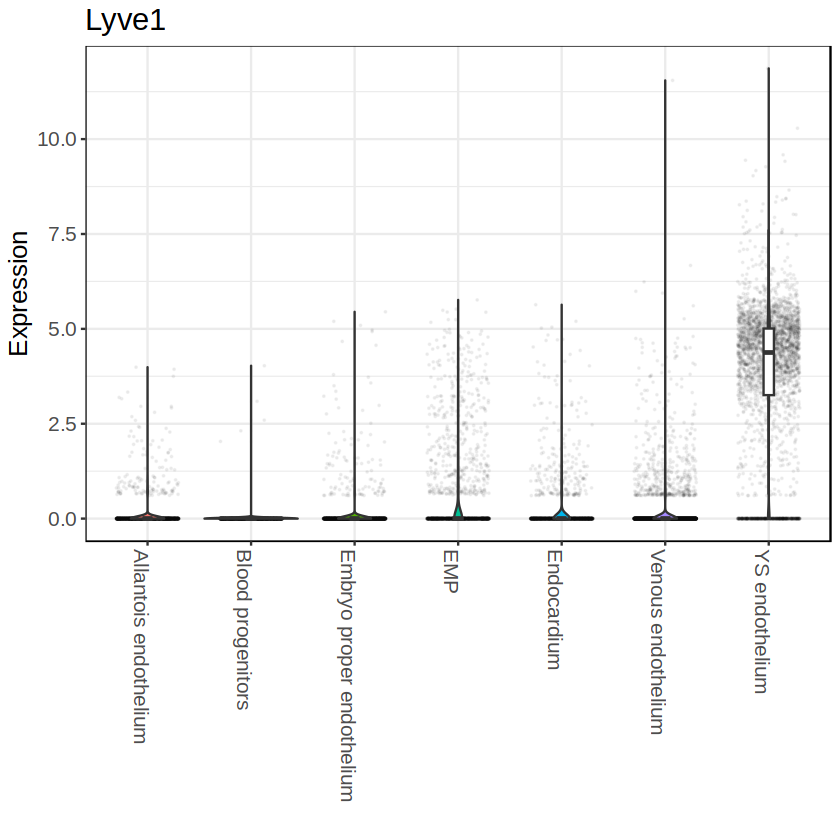

In [95]:
plot_gene('Lyve1', sce)

In [96]:
# Seurat marker gene detection
seurat = as.Seurat(sce)

ident = seurat@meta.data$celltype_extended_atlas
names(ident) = colnames(sce)
seurat@active.ident = ident

markers = FindAllMarkers(seurat)

Calculating cluster Allantois endothelium

Calculating cluster Blood progenitors

Calculating cluster Embryo proper endothelium

Calculating cluster EMP

Calculating cluster Endocardium

Calculating cluster Venous endothelium

Calculating cluster YS endothelium



In [183]:
markers.dt = as.data.table(markers)
top_n_markers <- markers.dt[order(-avg_log2FC)][, .SD[1:20], by = cluster]

In [184]:
sce_plot = sce[unique(top_n_markers$gene), ]

In [186]:
logcounts(sce_plot) = t(scale(t(logcounts(sce_plot))))

In [188]:
stats = lapply(unique(sce$celltype_extended_atlas), function(x){
    sce_sub = sce_plot[,sce$celltype_extended_atlas == x]
    stats.dt = data.table(gene = rownames(sce_sub),
                          celltype = x,
                          avg_expr = rowMeans(logcounts(sce_sub)),
                          perc_expr = rowMeans(logcounts(sce_sub)>0))
}) %>% rbindlist() %>% 
    .[,gene:=factor(gene, levels = unique(top_n_markers$gene))]

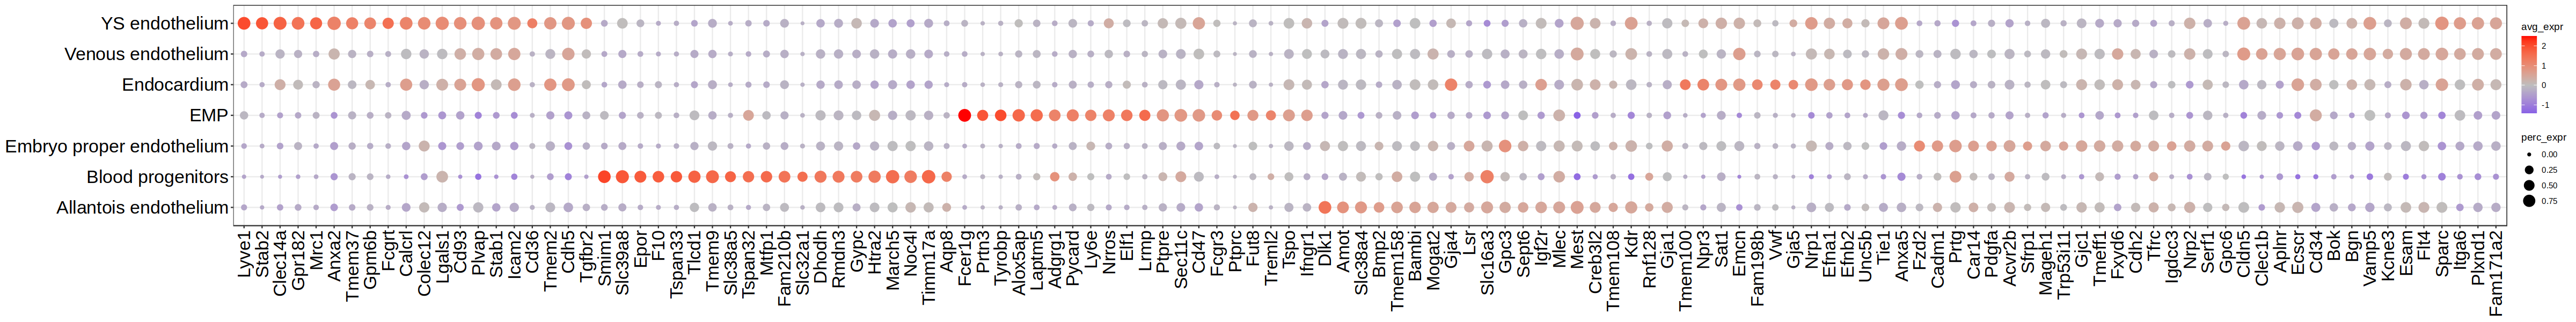

In [199]:
options(repr.plot.width=40, repr.plot.height=5)
ggplot(stats[perc_expr>=0,], aes(gene, celltype, size=perc_expr, col=avg_expr)) + 
    geom_point() +
    #viridis::scale_color_viridis() + 
    scale_color_gradient2(low='blue', mid='grey', high='red') + 
    theme_bw() + 
    theme(axis.text.x=element_text(angle=90, hjust=1, vjust=0.5),
          axis.text = element_text(color='black', size=20),
          axis.title = element_blank())